--- Starting Rows Of Dataset ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

/tmp/ipykernel_8466/1702458381.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


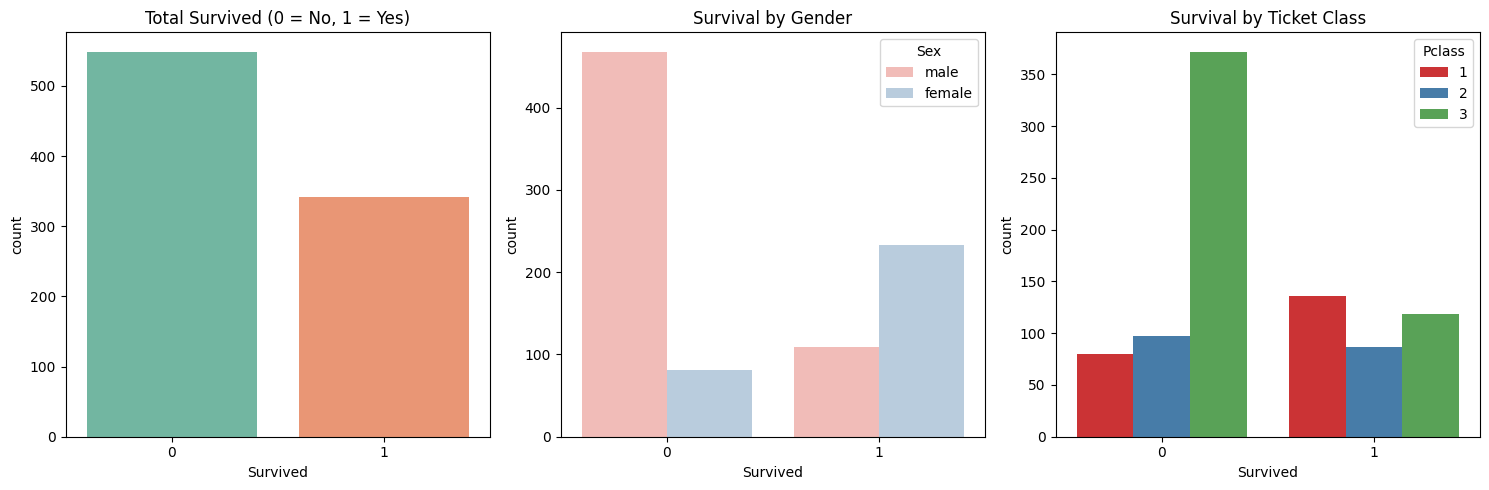

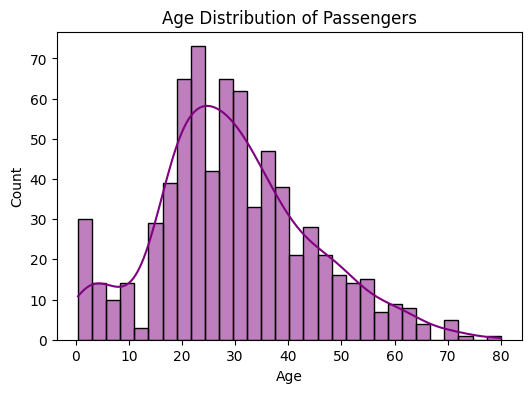

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dataset load karein (GitHub se direct)
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# 2. Data ki basic jankari (Statistical Summary)
print("--- Starting Rows Of Dataset ---")
print(df.head())

print("\n--- Columns and Data Types ---")
print(df.info())

print("\n--- Statistical Summary of Data ---")
print(df.describe())

print("\n---Number of missing Values ---")
print(df.isnull().sum())

# 3. VISUALIZATION (Graphs banana)
plt.figure(figsize=(15, 5))

# Graph 1: Kitne log bache (Survived vs Not Survived)
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Total Survived (0 = No, 1 = Yes)')

# Graph 2: Gender ke mutabik kitne log bache (Sex vs Survived)
plt.subplot(1, 3, 2)
sns.countplot(x='Survived', hue='Sex', data=df, palette='Pastel1')
plt.title('Survival by Gender')

# Graph 3: Ticket Class ke mutabik survival (Pclass vs Survived)
plt.subplot(1, 3, 3)
sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set1')
plt.title('Survival by Ticket Class')

plt.tight_layout()
plt.show()

# Graph 4: Age Distribution (Logon ki umar ka graph)
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='purple')
plt.title('Age Distribution of Passengers')
plt.show()

Task 2 - Model Accuracy: 82.68%


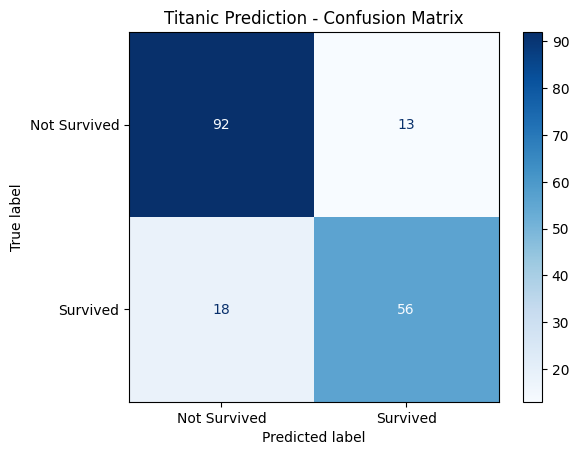

In [11]:
# ========================================================
# TASK 2: PREDICTIVE MODELING (MACHINE LEARNING)
# ========================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dataset load aur clean karna
df_ml = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df_ml['Age'] = df_ml['Age'].fillna(df_ml['Age'].median())
df_ml['Embarked'] = df_ml['Embarked'].fillna(df_ml['Embarked'].mode()[0])
df_ml['Sex'] = df_ml['Sex'].map({'male': 0, 'female': 1})
df_ml['Embarked'] = df_ml['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_ml[features]
y = df_ml['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Task 2 - Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# --- GRAPH BANANE KA CODE ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Titanic Prediction - Confusion Matrix")
plt.show()